In [ ]:
!pip install --upgrade datasets

!pip install transformers


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 15.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.8 MB/s eta 0:00:00


# PROGETTO 9
# Emotional classification and analysis
---
## Dataset:
 Hello-Simple/HC3 è un corpus di  confronto
  Human-Chatgpt, della tipologia "questions/answers", i cui dati provengono da varie fonti: Reddit, finance, medicine, open_qa e wiki. Il dataset è composto da 5 colonne (id, question, human_answer, chatgpt_answer, source).


#FASE 1: DATA PRE-PROCESSING
****
### **Caricamento e preparazione dei dati**


1.   Carica il dataset Hello-Simple/HC3

2.   Effettua una pulizia dei dati rimuovendo duplicati e testi nulli e un'analisi esplorativa del dataset

3.   Analisi esplorativa
      *   Distribuzione delle lunghezza delle risposte tra chatgpt e umano

4.   Statistica descrittiva
      *   Media  
      *   Mediana
      *   Deviazione standard
5.   Bilanciamento delle classi      









STEP 1: installazione e caricamento dati

In questa fase iniziale, vengono installate le librerie necessarie e carichiamo il dataset "Hello-Simple/HC3. Il dataset viene convertito in un dataframe di pandas per una manipolazione più "friendly".

In [ ]:
import pandas as pd

from collections import defaultdict

from sklearn.model_selection import train_test_split

from datasets import load_dataset

#---Carico il dataset di Hello-Simple
dataset= load_dataset("Hello-SimpleAI/HC3",name="all")

#Inizializzo un dataframe in pandas come df_emotion
df_emotion = pd.DataFrame(dataset['train'])



/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/24322 [00:00<?, ? examples/s]

In [ ]:
df_emotion.info()
#il metodo info() di pandas per visualizzare le informazioni sul DataFrame, che include il numero di colonne, il numero di righe, il tipo di dati, e altre informazioni utili.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24322 entries, 0 to 24321
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               24322 non-null  object
 1   question         24322 non-null  object
 2   human_answers    24322 non-null  object
 3   chatgpt_answers  24322 non-null  object
 4   source           24322 non-null  object
dtypes: object(5)
memory usage: 950.2+ KB


Step 2: Pulizia e analisi esplorativa


---
In questo secondo step, si passa alla pulizia dei dati che comprende:


*   Concatenazione liste stringhe in una sola singola stringa
*   rimozione duplicati
*   rimozione testi nulli
*verifica la distribuzione delle etichette dopo la pulizia

Successivamente, si passa all'analisi esplorativa dei dati.



In [ ]:
#Concateno le liste di stringhe in una singola stringa, faccio questo perche vorrei eseguire analisi testuale sulle risposte, e
#quindi potrebbe essere più comodo lavorare con singole stringhe piuttosto che con liste di stringhe.
df_emotion['human_answers'] = df_emotion['human_answers'].apply(lambda x: ','.join(x))
df_emotion['chatgpt_answers'] = df_emotion['chatgpt_answers'].apply(lambda x: ','.join(x))

# Rimuovi duplicati basati sulle colonne specificate
df_emotion = df_emotion.drop_duplicates(subset=['question', 'human_answers', 'chatgpt_answers', 'source'])

# Verifica la presenza di valori nulli nelle colonne dei testi
null_counts = df_emotion[['question', 'human_answers', 'chatgpt_answers']].isnull().sum()
print(null_counts)

# Rimuovi righe con testi nulli
df_emotion = df_emotion.dropna(subset=['question', 'human_answers', 'chatgpt_answers'])

# Conferma che i testi nulli sono stati rimossi
null_counts_after_removal = df_emotion[['question', 'human_answers', 'chatgpt_answers']].isnull().sum()
print(null_counts_after_removal)

# Verifica la distribuzione delle degli elementi contenuti in 'Source' dopo la pulizia
source_counts = df_emotion['source'].value_counts()
print(source_counts)


question           0
human_answers      0
chatgpt_answers    0
dtype: int64
question           0
human_answers      0
chatgpt_answers    0
dtype: int64
reddit_eli5    16603
finance         3933
medicine        1248
open_qa         1187
wiki_csai        842
Name: source, dtype: int64


STEP 3: Analisi esplorativa

---
Qui, esploriamo i dati per visualizzare la distribuzione della lunghezza delle domande, sia delle risposte umane che delle risposte generate da ChatGPT nel dataset. Questo tipo di visualizzazione è utile per ottenere un'idea della variabilità nella lunghezza dei testi nelle diverse colonne(human_answer e chatgpt_answer).



**Distribuzione della Lunghezza delle Risposte Umane e di ChatGPT:** Questi grafici aiuteranno a capire come varia la lunghezza delle risposte fornite dagli esseri umani e da ChatGPT. Si potrebbero identificare pattern interessanti o differenze nella lunghezza tra le risposte umane e quelle generate dal modello.

**Distribuzione delle Etichette "source":** Questo countplot ti mostra la distribuzione delle etichette "source" nel tuo dataset, aiutandoti a valutare il bilanciamento delle classi. In questo caso, sembra che ci sia un numero significativo di campioni da 'reddit_eli5'.


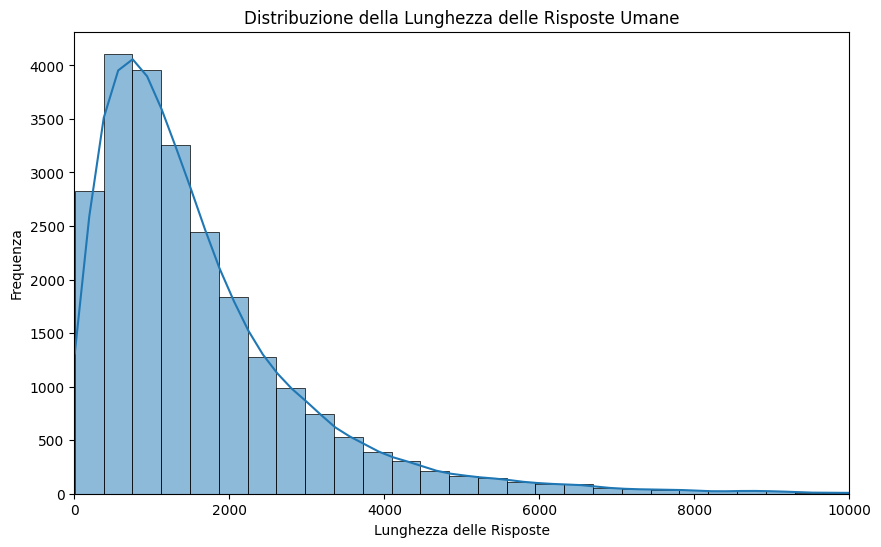

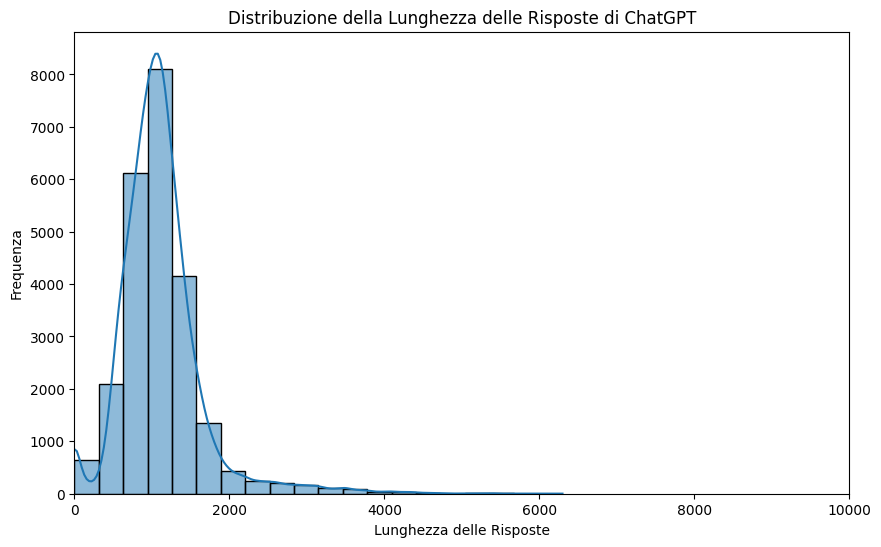

In [ ]:
import matplotlib.pyplot as plt

import seaborn as sns


# Lunghezza delle risposte umane
plt.figure(figsize=(10, 6))  # Imposta le dimensioni della figura
sns.histplot(list(df_emotion['human_answers'].apply(len)), bins=100, kde=True)
plt.title('Distribuzione della Lunghezza delle Risposte Umane')
plt.xlabel('Lunghezza delle Risposte')
plt.ylabel('Frequenza')
plt.xlim(0, 10000)  # Imposta i limiti dell'asse x da 0 a 10.000
plt.show()

# Lunghezza delle risposte di ChatGPT
plt.figure(figsize=(10, 6))
sns.histplot(list(df_emotion['chatgpt_answers'].apply(len)), bins=20, kde=True)
plt.title('Distribuzione della Lunghezza delle Risposte di ChatGPT')
plt.xlabel('Lunghezza delle Risposte')
plt.ylabel('Frequenza')
plt.xlim(0, 10000)  # Imposta i limiti dell'asse x da 0 a 10.000
plt.show()



LEGGENDA ISTOGRAMMA

* Asse x (Orizzontale): Rappresenta la lunghezza delle
risposte umane in termini di numero di caratteri.

* Asse y (Verticale): Rappresenta la frequenza delle risposte umane in ogni intervallo di lunghezza (numero di caratteri). La frequenza è il numero di risposte umane che rientrano in ciascun intervallo di lunghezza.

* Risposte Umane:
  * Asse delle Frequenze: Parte da 0 e arriva a circa 20.000.
  * Intervallo: Le barre sembrano essere definite con intervalli di 500, 1000, 1500, e così via.
  * Distribuzione: La distribuzione sembra concentrata nelle prime categorie di lunghezza, dal momento che le barre iniziano a diminuire dopo l'intervallo di 2.000.

* Risposte di ChatGPT:
  * Asse delle Frequenze: Parte da 0 e arriva a circa 8.000.
  * Intervallo: Le barre sembrano essere definite con intervalli regolari di 1.000, 2.000, 3.000, 4.000, 5.000 e così via.
  * Distribuzione: La distribuzione sembra più uniforme rispetto alle risposte umane, con un numero significativo di risposte in una varietà di lunghezze.

* Significato Generale:
  * Le risposte umane sembrano essere più concentrate in alcune lunghezze specifiche, mentre le risposte di ChatGPT sono più distribuite in lunghezze varie.La differenza nella scala dell'asse delle frequenze potrebbe indicare che ci sono più risposte umane rispetto alle risposte di ChatGPT, o viceversa.

* Conclusioni:
  Le risposte umane sembrano avere una distribuzione più concentrata, con una frequenza maggiore in alcune lunghezze specifiche.
Le risposte di ChatGPT, d'altra parte, sembrano essere più uniformemente distribuite in una varietà di lunghezze.
Questa differenza potrebbe suggerire che le risposte umane tendono ad avere una lunghezza più coerente o specifica rispetto alle risposte di ChatGPT, che possono variare di più in lunghezza.











STEP 4: STATISTICA DESCRITTIVA.


---
Qui, invece,calcoliamo:

*   Media
*   Mediana
*   Deviazione standard

Questi aiuterebbero a fornire una comprensione più quantitativa della distribuzione. Le statistiche sulla lunghezza delle risposte umane e di ChatGPT forniscono una panoramica quantitativa della distribuzione della lunghezza nel tuo dataset:

**Risposte Umane**:

* Media: La lunghezza media delle risposte umane è di circa 1633 caratteri.
* Mediana: La mediana, che rappresenta il punto centrale della distribuzione, è di 1226 caratteri.
* Deviazione Standard: La deviazione standard è elevata (circa 1515 caratteri), indicando una notevole variabilità nella lunghezza delle risposte umane.

**Risposte ChatGPT:**

* Media: La lunghezza media delle risposte generate da ChatGPT è di circa 1119 caratteri.
* Mediana: La mediana è di 1060 caratteri, indicando il punto centrale della distribuzione della lunghezza.
* Deviazione Standard: La deviazione standard è più bassa rispetto alle risposte umane (circa 541 caratteri), suggerendo una minore variabilità nella lunghezza delle risposte di ChatGPT.

**Interpretazione**:
In sintesi, le risposte umane nel dataset sembrano essere più lunghe e più variabili rispetto alle risposte generate da ChatGPT.



In [ ]:
# Calcola la lunghezza delle risposte umane e di ChatGPT
lunghezza_umane = df_emotion['human_answers'].apply(len)
lunghezza_chatgpt = df_emotion['chatgpt_answers'].apply(len)

# Calcola statistiche di base
media_umane = lunghezza_umane.mean()
mediana_umane = lunghezza_umane.median()
deviazione_std_umane = lunghezza_umane.std()

media_chatgpt = lunghezza_chatgpt.mean()
mediana_chatgpt = lunghezza_chatgpt.median()
deviazione_std_chatgpt = lunghezza_chatgpt.std()

# Stampa le statistiche
print("Statistiche Lunghezza Risposte Umane:")
print(f"Media: {media_umane}")
print(f"Mediana: {mediana_umane}")
print(f"Deviazione Standard: {deviazione_std_umane}")

print("\nStatistiche Lunghezza Risposte ChatGPT:")
print(f"Media: {media_chatgpt}")
print(f"Mediana: {mediana_chatgpt}")
print(f"Deviazione Standard: {deviazione_std_chatgpt}")


Statistiche Lunghezza Risposte Umane:
Media: 1633.2750178473943
Mediana: 1226.0
Deviazione Standard: 1515.8383939643213

Statistiche Lunghezza Risposte ChatGPT:
Media: 1119.9116029059758
Mediana: 1060.0
Deviazione Standard: 541.505250007321


Step 5: Bilanciamento delle classi


---
Infine, analiziamo il bilanciamento delle classi perchè ci aiuta a comprendere se le classi sono bilanciate o se c'è un forte sbilanciamento.
In questo caso, sembra che ci sia un numero significativo di campioni da 'reddit_eli5'.



In [ ]:
#Bilanciamento delle Classi:
#si valuta se le classi sono bilanciate o se c'è un forte sbilanciamento.
#In questo caso, sembra che ci sia un numero significativo di campioni da 'reddit_eli5'.

#visualizzazione di questo sbilanciamento:
sns.countplot(x='source', data=df_emotion)
plt.title('Distribuzione delle Etichette "source"')
plt.show()

#FASE 2: CLASSIFICATION

---
Utilizzo del modello per estrarre il sentimento:

1.  Suddividisione del dataset in set di addestramento e test.
2.  Definizione del modello BERT, tokenizer e
    funzione per analizzare il sentiment utilizzando il modello BERT
3.  Visualizzazione della distribuzione delle emozioni: accordo/discrepanza tra etichette umane e chatgpt




Step 1: Suddividisione del dataset in set di addestramento e test.


In [ ]:
train_size = 0.8  # 80% train
test_size = 0.2  # 20% test

# Dividi il dataset in train all'80% e il restante 20% tra val e test
df_train, df_test = train_test_split(df_emotion, train_size=train_size, test_size=test_size, random_state=42, stratify=df_emotion['source'])


In [ ]:
df_train

,id,question,human_answers,chatgpt_answers,source
8095,8095,If we were raised being told that flowers and ...,"It may be possible to condition us to enjoy "" ...",Our sense of smell is based on the ability of ...,reddit_eli5
13735,13735,Why do n't dogs live as long as people ? Would...,"Generally speaking , the smaller the * * mamma...",Dogs don't live as long as people because they...,reddit_eli5
16275,16275,Why is n't there a universal currency ? What w...,The answer that 's both simple and correct is ...,A universal currency is a type of money that i...,reddit_eli5
8160,8160,What will happen to the typical American if Th...,If the US government does not extend the conti...,"If the U.S government defaults, it means that ...",reddit_eli5
7546,7546,"What exactly is Tenure , and how does it work ...","Not "" impossible "" to fire , but more difficul...",Tenure is a system that protects the job secur...,reddit_eli5
...,...,...,...,...,...
11224,11224,I turned on my old guitar amp with nothing plu...,Radio waves are stupid easy to pick up on any ...,It sounds like your guitar amplifier is pickin...,reddit_eli5
12424,12424,If your heart has roughly 1 billion beats befo...,Two reasons . - Cardio does n't just exercise ...,Cardio exercise is good for you because it hel...,reddit_eli5
13120,13120,How does somebody develop Paranoid Schizophren...,"Although it is n't really understood , as is t...",Paranoid schizophrenia is a type of schizophre...,reddit_eli5
12669,12669,Twitter reported a Q2 loss of $ 144.6 million ...,Investors think they will be very profitable i...,"I'm sorry, but I am unable to browse the inter...",reddit_eli5


In [ ]:
df_test

,id,question,human_answers,chatgpt_answers,source
21446,21446,"Finance, Social Capital IPOA.U",(See also the question How many stocks I can e...,"I'm sorry, but I'm unable to provide informati...",finance
11170,11170,[ META ] Why are people suddenly usingto ask l...,Because they do n't know /r / AskReddit or /r ...,It is not uncommon for people to ask questions...,reddit_eli5
786,786,What causes an spinning image to look like it ...,This is called the [ wagon wheel effect ] ( UR...,An image of a spinning object can appear to ch...,reddit_eli5
6552,6552,How did this guy not break his legs / ankle ? ...,"Just a guess here , but it 's the same reason ...","I'm sorry, but it's not possible for me to exp...",reddit_eli5
7347,7347,"Why ca nt they make food zero calories , like ...",Soft drinks that contain zero cals are usually...,Calories are a measure of energy that is found...,reddit_eli5
...,...,...,...,...,...
12570,12570,"Why do dogs walk at an angle when walking "" st...","Because if they walk in a straight way , their...",Dogs walk at an angle when they are walking st...,reddit_eli5
9999,9999,how do rich people with massive net worth(Rang...,I would have to say most if not all hire profe...,Rich people with a large net worth generally h...,reddit_eli5
14899,14899,Why does it take time to uninstall a program f...,The operating system needs to know where every...,When you uninstall a program from your compute...,reddit_eli5
8134,8134,"Why do so many African Americans seem to say ""...",Sorry I ca nt post links for this since I 'm o...,It's important to note that not all African Am...,reddit_eli5


Step 2:Definizione del modello BERT, tokenizer e funzione per analizzare le emozioni utilizzando il modello BERT

* **Importazione delle librerie**:"*AutoTokenizer*" e "*AutoModelForSequenceClassification*" dal modulo *transformers* consentono di caricare automaticamente il tokenizer e il modello corrispondenti al modello specificato senza doverli selezionare manualmente.

* **Caricamento del tokenizer e del modello BERT**: "*tokenizer*" carica il tokenizer BERT specifico per la classificazione delle sequenze e addestrato su testi multilingue mentre "*model*" carica il modello BERT preaddestrato per la classificazione delle sequenze.

* **Funzione di Analisi delle Emozioni**:Questa funzione prende una stringa di testo in input, la tokenizza usando il tokenizer BERT, quindi esegue la classificazione delle emozioni utilizzando il modello BERT. Restituisce l'etichetta dell'emozione predetta e lo score associato.

* **Applicazione della funzione al set di test**:Applico dellla funzione alle risposte umane del set di test che memorizza l'etichetta e lo score di emozione predetti nei rispettivi DataFrame.

* **Stampa dei risultati**:Stampa le prime righe del DataFrame risultante, mostrando le etichette e gli score di emozione previsti per le risposte umane e di ChatGPT nel set di test.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Carica il tokenizer e il modello BERT specifico per la classificazione delle emozioni
tokenizer = AutoTokenizer.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")
model = AutoModelForSequenceClassification.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")

# Funzione per ottenere l'etichetta e il punteggio di emozione da una risposta
def get_emotion_info(text):
    # Tokenizza il testo
    tokens = tokenizer(text, return_tensors='pt', truncation=True)

    # Verifica la lunghezza della sequenza
    if tokens['input_ids'].size(1) > 512:
        # Se la sequenza è troppo lunga, taglia a 512 token
        tokens['input_ids'] = tokens['input_ids'][:, :512]
        tokens['attention_mask'] = tokens['attention_mask'][:, :512]

    # Esegui la classificazione delle emozioni
    result = model(**tokens)

    # Estrai l'etichetta e il punteggio dalla risposta del modello
    emotion_label = result.logits.argmax().item() #etichetta predetta
    emotion_score = result.logits.softmax(dim=1)[0, emotion_label].item() #probabilità associata all'etichetta predetta.
    return emotion_label, emotion_score


# Applica la funzione alle risposte umane e alle risposte di ChatGPT al set di test
df_test['human_emotion_label'], df_test['human_emotion_score'] = zip(*df_test['human_answers'].apply(get_emotion_info))
df_test['chatgpt_emotion_label'], df_test['chatgpt_emotion_score'] = zip(*df_test['chatgpt_answers'].apply(get_emotion_info))

# Stampa i risultati
print(df_test.head())


tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/669M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


          id                                           question  \
21446  21446                     Finance, Social Capital IPOA.U   
11170  11170  [ META ] Why are people suddenly usingto ask l...   
786      786  What causes an spinning image to look like it ...   
6552    6552  How did this guy not break his legs / ankle ? ...   
7347    7347  Why ca nt they make food zero calories , like ...   

                                           human_answers  \
21446  (See also the question How many stocks I can e...   
11170  Because they do n't know /r / AskReddit or /r ...   
786    This is called the [ wagon wheel effect ] ( UR...   
6552   Just a guess here , but it 's the same reason ...   
7347   Soft drinks that contain zero cals are usually...   

                                         chatgpt_answers       source  \
21446  I'm sorry, but I'm unable to provide informati...      finance   
11170  It is not uncommon for people to ask questions...  reddit_eli5   
786    An image o

Considerazioni generali:

I punteggi più alti possono indicare maggiore certezza nelle previsioni del modello. Punteggi più bassi potrebbero indicare incertezza o ambiguità nella classificazione. Una discrepanza tra l'etichetta assegnata e il punteggio potrebbe indicare situazioni in cui il modello umano è meno sicuro o ha assegnato una probabilità più bassa a un'etichetta particolare.

Inoltre, è possibile notare che:
1. **human_emotion_label e chatgpt_emotion_label**:
Le etichette di emozione umana e quelle generate da ChatGPT sembrano variare tra 1, 2 e 3. È possibile che questi numeri rappresentino categorie specifiche di emozioni.

2. **human_emotion_score e chatgpt_emotion_score**:
Gli score di emozione variano tra 0 e 1. Questi valori potrebbero rappresentare la confidenza del modello nella predizione dell'emozione. Ad esempio, valori più vicini a 1 indicano maggiore confidenza nella previsione dell'emozione.

3. **Confronto tra risposte umane e ChatGPT**:

* Analisi dellla riga 21446

  * analisi del testo: si tratta di una spiegazione dettagliata riguardante questioni finanziarie, in particolare l'esercizio di warrant azionari in relazione ai prezzi di mercato delle azioni e dei warrant.

  * Rispetto alle *etichette* e agli *score di emozione* assegnati, sia il modello di ChatGPT che l'umano hanno assegnato l'etichetta "2", che potrebbe corrispondere a un'emozione specifica. Tuttavia, gli score indicano una certa incertezza da entrambe le parti:

    * Il modello di ChatGPT ha assegnato uno score di 0.
    308914, indicando una certa incertezza o bassa fiducia nella previsione.

    * Dall'altro lato, il modello umano ha uno score di 0.477026, che, sebbene più alto rispetto a quello di ChatGPT, indica comunque una certa incertezza o mancanza di sicurezza nella previsione.

  In base a questi risultati, si può dedurre che entrambi i modelli, umano e ChatGPT, mostrano incertezza riguardo alle emozioni evocate dal testo finanziario. Potrebbe essere dovuto alla complessità del linguaggio finanziario e alle sottili sfumature di significato presenti nella spiegazione.


* Analisi dellla riga 11170:

  * riguarda una domanda sulla tendenza delle persone a porre domande cariche o a fare dichiarazioni politiche in modo travestito, cercando di far sembrare la domanda una semplice richiesta di opinioni. Le risposte umane sottolineano che questa pratica non è nuova e che le domande cariche possono essere problematiche.Osservando le etichette e gli score di emozione assegnati:

  * L'umano ha assegnato un'etichetta "1" e uno score di 0.356755.ChatGPT ha assegnato un'etichetta "2" e uno score più alto di 0.529869.

  * La discrepanza nelle etichette potrebbe indicare una divergenza nelle percezioni di emozioni. L'umano sembra associare una qualche forma di emotività negativa alla pratica di fare domande cariche, assegnando l'etichetta "1". D'altra parte, ChatGPT sembra percepire un'emozione diversa o meno negativa, assegnando l'etichetta "2".

Gli score suggeriscono che entrambi, sia l'umano che ChatGPT, sono abbastanza sicuri della loro previsione. L'umano mostra uno score più basso, indicando una certa incertezza, mentre ChatGPT mostra uno score più alto, indicando una maggiore sicurezza nella sua previsione.

In generale,in base alle analisi delle risposte umane e di ChatGPT relative alle domande cariche e alle dichiarazioni politiche, possiamo trarre alcune considerazioni:

**Divergenza nelle Percezioni Emotive**: Si osserva una discrepanza nelle etichette di emozione assegnate da umani e ChatGPT. Mentre l'umano sembra associare un'emozione negativa (etichetta "1") a tali domande, ChatGPT assegna un'etichetta "2", suggerendo una percezione meno negativa o una divergenza nelle interpretazioni emotive.

**Incidenza della Sicurezza nella Previsione**: Gli score di emozione indicano che l'umano mostra uno score più basso, suggerendo una certa incertezza nella previsione emotiva. D'altra parte, ChatGPT mostra uno score più alto, indicando una maggiore sicurezza nella sua previsione.


**Differenze nelle Prospettive**: La divergenza potrebbe riflettere diverse prospettive sul tema delle domande cariche e delle dichiarazioni politiche. Mentre l'umano potrebbe percepirle più negativamente, ChatGPT potrebbe interpretarle in modo più neutro o meno negativo.

In conclusione, la comparazione delle risposte umane e di ChatGPT evidenzia la complessità nella valutazione delle emozioni, con diverse interpretazioni e prospettive che emergono nei confronti di argomenti sensibili come le domande cariche.








Step 3: Visualizzazione dell'accordo/discrepanza tra le etichette delle emozioni umane e chatgpt.

Proporzione di risposte in cui c'è accordo tra le etichette umane e quelle di chatgpt rispetto a quelle in cui c'è discrepanza.

In [ ]:
import matplotlib.pyplot as plt

import seaborn as sns

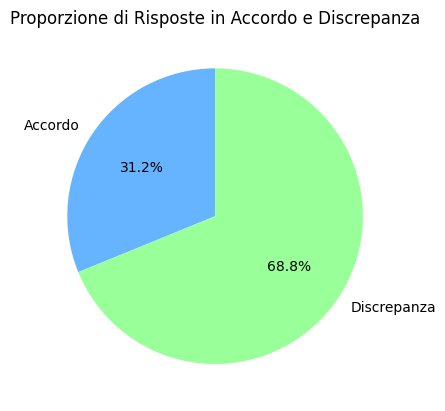

In [ ]:
# Conta il numero di risposte in cui c'è accordo tra etichette umane e del modello
accordo_count = df_test[df_test['human_emotion_label'] == df_test['chatgpt_emotion_label']].shape[0]

# Conta il numero di risposte in cui c'è discrepanza tra etichette umane e del modello
discrepanza_count = df_test[df_test['human_emotion_label'] != df_test['chatgpt_emotion_label']].shape[0]

# Dati per il grafico a torta
sizes = [accordo_count, discrepanza_count]

# Colori delle fette
colors = ['#66b3ff', '#99ff99']

# Crea il grafico a torta
plt.pie(sizes, labels=['Accordo', 'Discrepanza'], autopct='%1.1f%%', colors=colors, startangle=90)

# Aggiungi un titolo
plt.title('Proporzione di Risposte in Accordo e Discrepanza')

# Mostra il grafico
plt.show()


#FASE 3: EMOTION ANALYSIS

---
Analisi del sentimento delle frasi rispetto alle etichette del dataset:

1.  Vedere come il profilo delle emozioni cambia quando la risposta è generata dall'umano e da chatgpt
2.  Calcolare il coefficiente di correlazione tra umano e chatgpt.
3.  Misurare lo scostamento assoluto medio tra le etichette di emozioni umane e chatgpt.
4. Calcolare la matrice di confusione.





Step 1: Vedere come il profilo delle emozioni cambia quando la risposta è generata dall'umano e da chatgpt

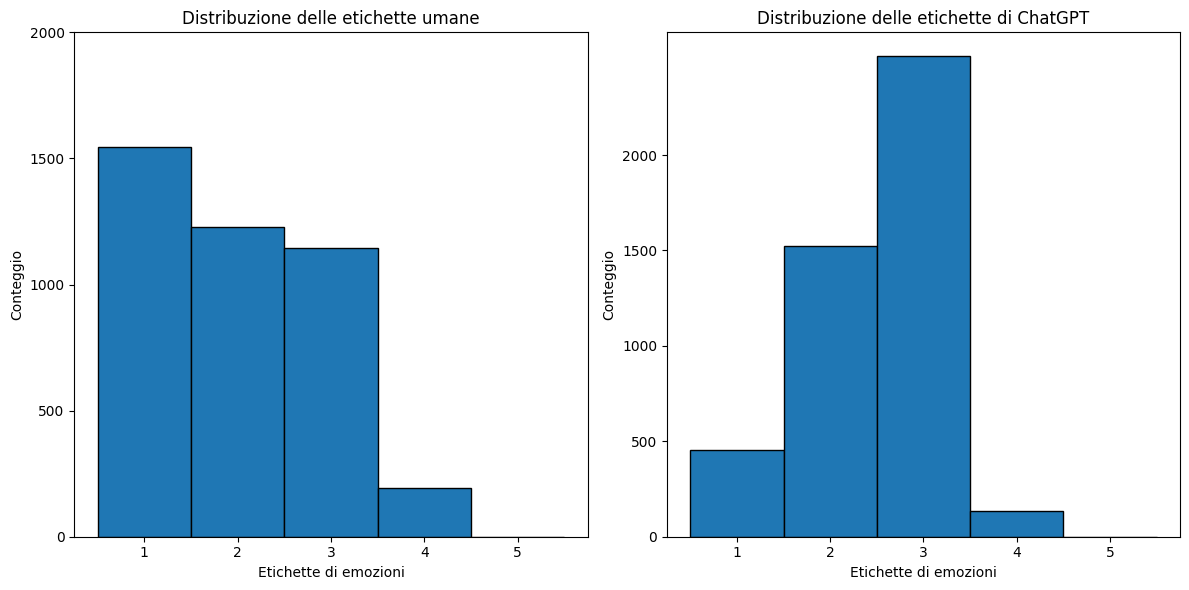

In [ ]:

# Creare un istogramma delle etichette umane
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df_test['human_emotion_label'], bins=range(1, 7), align='left', edgecolor='black')
plt.title('Distribuzione delle etichette umane')
plt.xlabel('Etichette di emozioni')
plt.ylabel('Conteggio')
plt.yticks(range(0, 2001, 500))

# Creare un istogramma delle etichette di ChatGPT
plt.subplot(1, 2, 2)
plt.hist(df_test['chatgpt_emotion_label'], bins=range(1, 7), align='left', edgecolor='black')
plt.title('Distribuzione delle etichette di ChatGPT')
plt.xlabel('Etichette di emozioni')
plt.ylabel('Conteggio')
plt.yticks(range(0, 2001, 500))

plt.tight_layout()
plt.show()


LEGGENDA:

Asse x (Orizzontale): Rappresenta le diverse etichette di emozioni da 1 a 5.

Asse y (Verticale): Rappresenta il conteggio delle risposte umane o di ChatGPT che hanno ricevuto ciascuna etichetta di emozione.



Step 2:Calcolare il coefficiente di correlazione tra umano e chatgpt.

In [ ]:
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

# Calcolo del coefficiente di correlazione tra umano e ChatGPT
correlation_coefficient, _ = pearsonr(df_test['human_emotion_label'], df_test['chatgpt_emotion_label'])
print(f"Coeficiente di correlazione tra umano e ChatGPT: {correlation_coefficient}")


Coeficiente di correlazione tra umano e ChatGPT: 0.24364641041123614


Il coefficiente di correlazione misura la forza e la direzione di una relazione lineare tra due variabili. Il range del coefficiente di correlazione è compreso tra -1 e 1:

Un valore di 1 indica una correlazione positiva perfetta, il che significa che le variabili si muovono insieme in modo lineare.
Un valore di -1 indica una correlazione negativa perfetta, il che significa che le variabili si muovono in direzioni opposte in modo lineare.
Un valore vicino a 0 indica una correlazione debole o assente.
In questo caso, il coefficiente di correlazione tra le etichette di emozioni umane e le etichette di emozioni di ChatGPT è 0.2436. Questo valore positivo suggerisce una correlazione debole e positiva tra le etichette umane e quelle di ChatGPT. In altre parole, c'è una piccola tendenza in cui le emozioni umane e le etichette di ChatGPT sono associate in modo simile, ma la relazione è debole.

Tuttavia, una correlazione debole suggerisce che ci potrebbero essere limitazioni o differenze nelle previsioni delle emozioni tra le risposte umane e quelle generate da ChatGPT.

Step 3: Misurare lo scostamento assoluto medio tra le etichette di emozioni umane e chatgpt.

In [ ]:
# Misurazione del valore assoluto dello scostamento tra risposte umane e chatgpt
absolute_deviation = mean_absolute_error(df_test['human_emotion_label'], df_test['chatgpt_emotion_label'])
print(f"Scostamento assoluto tra umano e ChatGPT: {absolute_deviation}")


Scostamento assoluto tra umano e ChatGPT: 1.0526978794877178


Il valore dello scostamento assoluto (1.0527) rappresenta la differenza media assoluta tra le etichette di emozioni umane e le etichette di emozioni di ChatGPT. In altre parole, è una misura della discrepanza media tra le risposte umane e quelle generate da ChatGPT in termini di emozioni.

Questo valore relativamente alto indica che, in media, c'è una differenza significativa tra le etichette di emozioni umane e quelle di ChatGPT.

Step 4: Calcolare la matrice di confusione


---
La matrice di confusione è una tabella che viene utilizzata per valutare le prestazioni di un modello di classificazione, confrontando le etichette predette dal modello con le etichette reali dei dati. È particolarmente utile quando si lavora con problemi di classificazione multiclasse, come nel caso delle emozioni umane e di ChatGPT.

La matrice di confusione ha le seguenti componenti:

* Veri positivi (TP): sono i casi in cui il modello ha predetto correttamente una classe positiva.
* Falsi positivi (FP): sono i casi in cui il modello ha predetto erroneamente una classe positiva quando in realtà era negativa.
* Veri negativi (TN): sono i casi in cui il modello ha predetto correttamente una classe negativa.
* Falsi negativi (FN): sono i casi in cui il modello ha predetto erroneamente una classe negativa quando in realtà era positiva.


In [ ]:
from sklearn.metrics import confusion_matrix

# Ottenere le etichette reali e predette
y_true = df_test['human_emotion_label']
y_pred = df_test['chatgpt_emotion_label']

# Calcolare la matrice di confusione
conf_matrix = confusion_matrix(y_true, y_pred)

# Visualizzare la matrice di confusione
print(conf_matrix)


[[ 55 101 230 252  12]
 [ 36 203 584 699  22]
 [ 20  93 408 679  30]
 [ 21  50 243 790  42]
 [  3   8  56  97  29]]


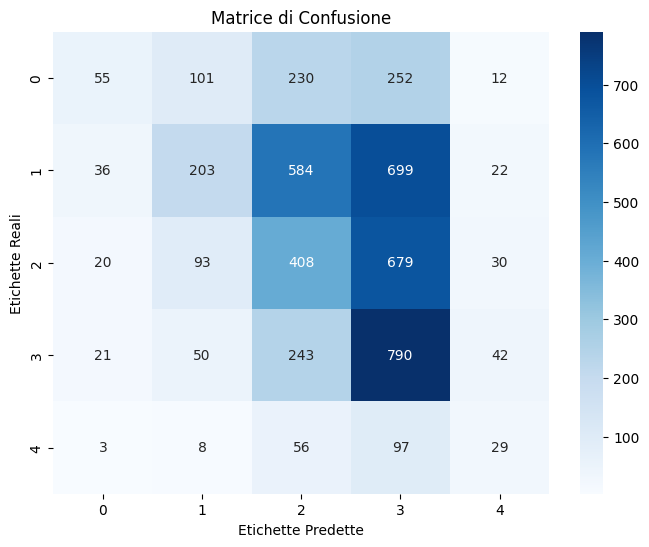

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creare la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')

# Aggiungere titoli e etichette
plt.title('Matrice di Confusione')
plt.xlabel('Etichette Predette')
plt.ylabel('Etichette Reali')

# Mostrare la heatmap
plt.show()


La matrice di confusione è una tabella che mostra le prestazioni di un modello di classificazione su un set di dati di test. Ogni cella della matrice rappresenta il numero di istanze in cui l'etichetta reale è stata predetta correttamente o erroneamente dal modello.

Nella heatmap, ogni cella della matrice di confusione è colorata in base al numero di istanze correttamente predette (TP e TN) o erroneamente predette (FP e FN). La scala di colori utilizzata è "Blues", dove il colore più chiaro indica un numero più basso di istanze e il colore più scuro indica un numero più alto di istanze.

Le etichette sull'asse x rappresentano le etichette predette dal modello, mentre le etichette sull'asse y rappresentano le etichette reali. Ad esempio, se la cella (1, 2) ha un valore di 10, significa che il modello ha predetto correttamente 10 istanze con etichetta 1 come etichetta 2.

In questo caso, la heatmap mostra che il modello ha predetto correttamente la maggior parte delle istanze, come indicato dai valori più alti sulla diagonale principale della matrice. Tuttavia, ci sono anche istanze in cui il modello ha predetto erroneamente le etichette, come indicato dai valori non nulli al di fuori della diagonale principale.

In base alla matrice di confusione, possiamo concludere che il modello ha una buona capacità di predire le etichette delle emozioni umane e di ChatGPT. Tuttavia, ci sono casi in cui il modello ha predetto erroneamente le etichette. Questo potrebbe essere dovuto a varie ragioni, come la complessità delle risposte, la presenza di ambiguità nel testo o la mancanza di informazioni contestuali.